[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JeremieJakubowicz/xhec-advanced-ai-2026/blob/main/Session3/Session3-Attention.ipynb)

# Session 3 — Attention: looking back instead of remembering

**Advanced AI: Language Models & Agents** · X-HEC · Fall 2026 · Author: Jérémie Jakubowicz

Session 2 ended with a scoreboard, table < CNN < LSTM, and three limits of the winner: its training signal still fades with distance, it reads one token at a time, and everything it remembers must fit in one fixed-size vector. This session builds the mechanism that lifts the three at once. Instead of carrying a summary forward, every position **looks directly at every earlier position** and learns *what* to look for. That mechanism is called **attention**; stacked with a small per-position network, it is the **Transformer**, the architecture of every large language model since 2018. We build it from scratch, train it on Hugo with the exact protocol of session 2, and measure what it buys.

**What you will take away from this session**

1. **Attention is a soft lookup.** The table of session 1 looked up an exact context; attention looks up the past by similarity, with learned queries, keys and values, and a softmax that spreads the lookup over every earlier position.
2. **The Transformer block.** Attention to gather, a small network to think, a residual stream to keep, layer normalisation to stabilise: the same residual stream as the CNN of session 2, with a window that is the whole context.
3. **What it buys, measured.** The gradient reaches any distance in one hop; every position is computed at once; the memory is the past itself, not a summary of it. On the same corpus, with fewer parameters than the LSTM, it wins; it takes more from the far context than the LSTM, and it can copy a rare word seen earlier, which the LSTM cannot.

In [ ]:
# On Google Colab, run this cell first, on a GPU runtime (Runtime > Change runtime type > T4 GPU).
# torch, pandas, matplotlib and scikit-learn are preinstalled there; tokenizers is not.
%pip install -q tokenizers

## 0. Setup: everything from session 2, in one cell

Same corpus, same splits, same tokenizer, same single measurement (the surprise on unseen text, in bits per character), same training loop. The three networks of session 2 are reloaded from their checkpoints: they are the models to beat.

In [2]:
import os, math, time, random, urllib.request, warnings
from collections import defaultdict
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from tokenizers import Tokenizer

BASE = "https://raw.githubusercontent.com/JeremieJakubowicz/xhec-advanced-ai-2026/main/"
def fetch(relative_path):
    local = os.path.basename(relative_path)
    if not os.path.exists(local):
        print("downloading", relative_path); urllib.request.urlretrieve(BASE + relative_path, local)
    return local

hugo = " ".join(open(fetch("data/hugotexts.txt"), encoding="utf-8").read().split())   # whitespace collapsed to one space
tok = Tokenizer.from_file(fetch("data/hugo_bpe_8k.json")); V = tok.get_vocab_size()
a, b = int(0.85 * len(hugo)), int(0.90 * len(hugo))
text = dict(train=hugo[:a], val=hugo[a:b], test=hugo[b:])
encode = lambda s: [i for j in range(0, len(s), 200_000) for i in tok.encode(s[j:j + 200_000]).ids]
data = {k: torch.tensor(encode(v)) for k, v in text.items()}
chars_per_token = {k: len(text[k]) / len(data[k]) for k in data}
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
TABLE_BITS_PER_CHAR = 1.93                                   # the smoothed table of session 2, memory 2
CTX = 128                                                    # the window every model is trained and scored on

def batch(split, n, length):
    d = data[split]; ix = torch.randint(0, len(d) - length - 1, (n,))
    return (torch.stack([d[i:i + length] for i in ix]).to(device), torch.stack([d[i + 1:i + length + 1] for i in ix]).to(device))

def surprise(model, split="test", window=CTX, warm=64, limit=None, batch_size=64):
    d = data[split][:limit]; starts = range(0, len(d) - window - 1, window - warm); model.eval(); nll, n = 0.0, 0
    with torch.no_grad():
        for b0 in range(0, len(starts), batch_size):
            idx = starts[b0:b0 + batch_size]
            x = torch.stack([d[i:i + window] for i in idx]).to(device); y = torch.stack([d[i + 1:i + window + 1] for i in idx]).to(device)
            losses = F.cross_entropy(model(x).reshape(-1, V), y.reshape(-1), reduction="none").reshape(len(idx), window)
            nll += losses[:, warm:].sum().item(); n += len(idx) * (window - warm)
    model.train(); return nll / n

def report(name, nats, split="test"):
    return dict(model=name, loss=round(nats, 3), perplexity=round(math.exp(nats), 1), bits_per_char=round(nats / math.log(2) / chars_per_token[split], 3))

def train(model, seconds, lr=2e-3, batch_size=64, window=CTX, log_every=250, warmup=100):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    history, best, best_state, t0, step = [], float("inf"), None, time.time(), 0
    while time.time() - t0 < seconds:
        for g in opt.param_groups: g["lr"] = lr * min(1.0, (step + 1) / warmup)      # a short warm-up, which Transformers like
        x, y = batch("train", batch_size, window)
        loss = F.cross_entropy(model(x).reshape(-1, V), y.reshape(-1))
        opt.zero_grad(set_to_none=True); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step(); step += 1
        if step % log_every == 0:
            val = surprise(model, "val", limit=40_000); history.append((step, time.time() - t0, loss.item(), val))
            if val < best: best, best_state = val, {k: v.detach().clone() for k, v in model.state_dict().items()}
            print(f"step {step:5d}  {time.time() - t0:4.0f}s  train loss {loss.item():.3f}  val loss {val:.3f}")
    model.load_state_dict(best_state)
    return pd.DataFrame(history, columns=["step", "seconds", "train_loss", "val_loss"])

@torch.no_grad()
def generate(model, prompt, n=60, temperature=0.8, seed=0):
    g = torch.Generator(device="cpu").manual_seed(seed); ids = tok.encode(prompt).ids; model.eval()
    for _ in range(n):
        logits = model(torch.tensor([ids[-(CTX - 1):]]).to(device))[0, -1] / temperature
        ids.append(torch.multinomial(torch.softmax(logits, -1).cpu(), 1, generator=g).item())
    model.train(); return tok.decode(ids)

@torch.no_grad()
def context_curve(model, ks=(1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64, 96, 128), n=600, K=CTX):
    torch.manual_seed(1); x, y = batch("test", n, K); out = {}; model.eval()
    for k in ks:
        nll = sum(F.cross_entropy(model(x[j:j + 200, K - k:])[:, -1], y[j:j + 200, -1], reduction="sum").item() for j in range(0, n, 200))
        out[k] = nll / n / math.log(2) / chars_per_token["test"]
    model.train(); return pd.Series(out, name="bits per char")

class LocalCNN(nn.Module):                                   # session 2, part A
    def __init__(self, d=256, layers=4, kernel=3, dropout=0.2):
        super().__init__(); self.emb = nn.Embedding(V, d); self.convs = nn.ModuleList([nn.Conv1d(d, 2 * d, kernel) for _ in range(layers)])
        self.norm, self.drop, self.kernel = nn.LayerNorm(d), nn.Dropout(dropout), kernel
        nn.init.normal_(self.emb.weight, std=d ** -0.5)
    def forward(self, x, emb=None):
        h = self.drop(self.emb(x) if emb is None else emb).transpose(1, 2)
        for conv in self.convs:
            u, g = conv(F.pad(h, (self.kernel - 1, 0))).chunk(2, dim=1); h = h + self.drop(u * torch.sigmoid(g))
        return self.norm(h.transpose(1, 2)) @ self.emb.weight.T

class Recurrent(nn.Module):                                  # session 2, part B: the simple RNN and the LSTM
    def __init__(self, kind="rnn", d=256, hidden=512, layers=2, dropout=0.3):
        super().__init__(); self.emb, self.drop = nn.Embedding(V, d), nn.Dropout(dropout)
        self.rnn = {"rnn": nn.RNN, "lstm": nn.LSTM}[kind](d, hidden, layers, batch_first=True, dropout=dropout)
        self.proj = nn.Linear(hidden, d); nn.init.normal_(self.emb.weight, std=d ** -0.5)
    def forward(self, x, emb=None):
        h, _ = self.rnn(self.drop(self.emb(x) if emb is None else emb)); return self.proj(self.drop(h)) @ self.emb.weight.T

def load_checkpoint(model, path, rename=lambda k: k):
    state = torch.load(fetch(path), map_location="cpu")
    model.load_state_dict({rename(k): v.float() for k, v in state.items()}); return model.to(device)

cnn = load_checkpoint(LocalCNN(), "Session2/checkpoints/cnn.pt")
rnn = load_checkpoint(Recurrent("rnn"), "Session2/checkpoints/rnn.pt")
lstm = load_checkpoint(Recurrent("lstm"), "Session2/checkpoints/lstm.pt")
scoreboard = [report("smoothed table, memory 2", TABLE_BITS_PER_CHAR * math.log(2) * chars_per_token["test"]),
              report("local CNN", surprise(cnn)), report("simple RNN", surprise(rnn)), report("LSTM", surprise(lstm))]
print(f"device: {device}"); pd.DataFrame(scoreboard)

device: mps


,model,loss,perplexity,bits_per_char
0,"smoothed table, memory 2",4.676,107.4,1.930
1,local CNN,4.119,61.5,1.700
2,simple RNN,4.233,68.9,1.747
3,LSTM,3.966,52.8,1.637


## 1. Where we are

Three limits of the LSTM closed session 2, and they are the specification of what comes next.

1. **The gradient still decays with distance.** The gates slow the decay down; they do not remove it. The LSTM's context curve went flat around a hundred tokens.
2. **One step at a time.** The state at position $t$ needs the state at $t-1$. A recurrent network cannot process the positions of a text in parallel; a convolution can, which is why it is cheap, but its window is fixed.
3. **A bottleneck.** Everything the model knows about the text so far must fit in one vector of 512 numbers, rewritten at every token.

The CNN had none of the first two problems and could not see far; the LSTM sees far and has all three. We want the reach of the LSTM with the parallelism of the CNN, and no summary in between.

## 2. Looking back instead of remembering

### 2.1 The crudest way to look back: an average

Suppose that, to predict the next token, a position simply took the **average of the vectors of all the tokens before it**. No memory to carry, no window: every earlier token is one step away, and all positions can be computed at once. It is a real model, and a bad one, for two reasons that the next three lines show.

In [3]:
E = cnn.emb.weight.detach()                                   # any embedding table will do for the point
bag = lambda s: E[torch.tensor(tok.encode(s).ids, device=device)].mean(0)
one, two = " le chat mange la souris", " la souris mange le chat"      # a leading space, so that both are made of the same five tokens
print(f"tokens: {tok.encode(one).tokens}  vs  {tok.encode(two).tokens}")
print(f"distance between the two averages: {(bag(one) - bag(two)).norm().item():.3f}")

tokens: ['Ġle', 'Ġchat', 'Ġmange', 'Ġla', 'Ġsour', 'is']  vs  ['Ġla', 'Ġsour', 'is', 'Ġmange', 'Ġle', 'Ġchat']
distance between the two averages: 0.000


An average **forgets the order** (the two sentences get the same vector, and the second one is the sad story) and **weighs every token the same**, the name that matters as much as the comma. Both defects have the same cure: **weights that depend on what is being looked for and on what is there.**

### 2.2 The table of session 1, revisited: a soft lookup

Session 1 predicted the next token by looking up the exact context in a table of counts. Call the context the *key* under which the table stores what followed, and the thing it stores the *value*. The lookup fails as soon as the exact key was never seen, which is most of the time, and it cannot see beyond the two or three tokens of the key.

Attention keeps the idea and softens every part of it. At position $t$, the model computes a **query** $q_t$: what it is looking for. Every earlier position $s \le t$ offers a **key** $k_s$: what it contains, and a **value** $v_s$: what it would contribute if picked. The query is compared to every key by a dot product, the scores are turned into weights that sum to one by a softmax, and the output is the weighted sum of the values:

$$\alpha_{t,s} = \frac{\exp(q_t \cdot k_s / \sqrt{d_k})}{\sum_{r \le t} \exp(q_t \cdot k_r / \sqrt{d_k})}, \qquad\qquad o_t = \sum_{s \le t} \alpha_{t,s} \, v_s .$$

Three differences with the table. The match is a *similarity* (a dot product), not an equality, so a key never seen before still scores; the lookup is *soft*, spread over all positions in proportion to their score, so it is differentiable and can be learned; and queries, keys and values are all *computed from the token vectors* by learned matrices, $q_t = W_Q h_t$, $k_s = W_K h_s$, $v_s = W_V h_s$, so the model learns what to look for, how to advertise what it holds, and what to hand over. The division by $\sqrt{d_k}$, the dimension of the keys, keeps the scores of a reasonable size whatever $d_k$ (a dot product of $d_k$ independent terms has a standard deviation growing like $\sqrt{d_k}$). The average of section 2.1 is the special case where all scores are equal.

The condition $s \le t$ is the **causal mask**, the same rule as the causal convolution: a position must not see the tokens it is supposed to predict. Without it the model would read the answer.

## 3. One head of attention, by hand

Everything in section 2.2 is a dozen lines of tensor arithmetic. For a whole window at once, stack the queries, keys and values of the $T$ positions into matrices $Q, K, V \in \mathbb{R}^{T \times d_k}$: the scores are $Q K^\top / \sqrt{d_k}$, a $T \times T$ matrix with one row per query and one column per key; the mask sets the entries above the diagonal to $-\infty$, so that the softmax gives them a weight of exactly zero; the softmax is taken row by row; the output is the product with $V$:

$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}} + M\right) V, \qquad M_{t,s} = \begin{cases} 0 & s \le t \\ -\infty & s > t \end{cases}$$

The whole window is one matrix product: no loop over the positions, no state carried from one to the next. That is the parallelism of the CNN, with a window that is the whole context.

In [4]:
def causal_attention(q, k, v):
    """q, k, v: (..., T, dk). Every position attends to itself and the positions before it. Returns (output, weights)."""
    T = q.shape[-2]
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])                      # (..., T, T): one score per (query, key) pair
    mask = torch.triu(torch.ones(T, T, dtype=torch.bool, device=q.device), diagonal=1)
    weights = torch.softmax(scores.masked_fill(mask, float("-inf")), dim=-1)      # rows sum to one, zeros above the diagonal
    return weights @ v, weights

torch.manual_seed(0)
q, k, v = torch.randn(5, 2), torch.randn(5, 2), torch.randn(5, 2)                   # five positions, two-dimensional keys, no training
out, w = causal_attention(q, k, v)
print("attention weights (row t: how much position t looks at each earlier position)"); print(w.numpy().round(2))
print("rows sum to", w.sum(1).numpy().round(2))

attention weights (row t: how much position t looks at each earlier position)
[[1.   0.   0.   0.   0.  ]
 [0.32 0.68 0.   0.   0.  ]
 [0.33 0.16 0.51 0.   0.  ]
 [0.22 0.35 0.18 0.25 0.  ]
 [0.17 0.15 0.22 0.16 0.31]]
rows sum to [1. 1. 1. 1. 1.]


Read the matrix by rows. Position 1 can only look at itself, so its row is $(1, 0, 0, 0, 0)$; position 5 spreads its weight over the five positions it can see, according to how well its query matches their keys. With random $q$, $k$ the weights mean nothing yet; training will make them mean something, which section 7 shows.

## 4. Several heads, and the positions

**Several heads.** A single lookup is a single question. The Transformer asks several at once: $H$ heads, each with its own $W_Q, W_K, W_V$ and its own $T \times T$ matrix of weights, working on a slice of $d_k = d / H$ dimensions, so that the total cost stays that of one lookup of dimension $d$. Their outputs are concatenated and mixed by one more matrix $W_O$:

$$\mathrm{MultiHead}(h) = W_O \, \big[\mathrm{head}_1 ; \dots ; \mathrm{head}_H\big], \qquad \mathrm{head}_i = \mathrm{Attention}\big(h \, W_Q^{(i)}, \; h \, W_K^{(i)}, \; h \, W_V^{(i)}\big) .$$

Here $d = 256$ and $H = 4$, so each head works in 64 dimensions. In the code the three matrices of the four heads are one linear layer of $d \to 3d$, split afterwards.

**The positions.** Nothing above depends on where a token is: permute the earlier positions and every query sees the same set of keys and values, so the output is the same. Attention alone is the bag of section 2.1 with better weights. The fix is to tell each position where it is: the input vector of the token at position $t$ is its embedding **plus a learned vector for the position $t$**, one per position from 1 to the context length. Keys and queries then carry position as well as content, and a head can learn to look at "the previous token" as easily as at "the last name".

In [5]:
class Attention(nn.Module):
    """Multi-head causal self-attention: every position looks at itself and the positions before it, through H heads."""
    def __init__(self, d, heads, dropout):
        super().__init__(); self.heads, self.dk = heads, d // heads
        self.qkv = nn.Linear(d, 3 * d)                                    # W_Q, W_K, W_V of all heads, stacked
        self.out = nn.Linear(d, d)                                        # W_O: mixes the heads back into one vector
        self.drop = nn.Dropout(dropout); self.head_mask = None; self.weights = None
    def forward(self, h):
        B, T, d = h.shape
        q, k, v = self.qkv(h).view(B, T, 3, self.heads, self.dk).permute(2, 0, 3, 1, 4)   # each (B, heads, T, dk)
        y, w = causal_attention(q, k, v)                                  # y (B, heads, T, dk), w (B, heads, T, T)
        if not self.training: self.weights = w.detach()                  # kept for the figures of section 7
        if self.head_mask is not None: y = y * self.head_mask.view(1, -1, 1, 1)   # for the ablations of section 8
        return self.drop(self.out(self.drop(y).transpose(1, 2).reshape(B, T, d)))

## 5. The block, and the whole model

Attention gathers; it does not compute much on what it gathered (a weighted sum of values). Each block therefore adds a second half: a small two-layer network applied to **each position separately**, the same at every position, with a hidden width of $4d$ and a smooth nonlinearity (GELU). Attention moves information *between* positions; the small network processes it *within* a position. Both are wrapped in the residual stream of session 2: each half reads the stream, and *adds* its result to it; a layer normalisation in front of each half keeps the numbers well scaled (the *pre-norm* arrangement, the one GPT-2 uses):

$$h \leftarrow h + \mathrm{MultiHead}\big(\mathrm{LN}_1(h)\big), \qquad\qquad h \leftarrow h + W_2 \, \mathrm{GELU}\big(W_1 \, \mathrm{LN}_2(h) + b_1\big) + b_2 .$$

*The whole model.* Let $x_1, \dots, x_T$ be the tokens of a window, $E \in \mathbb{R}^{V \times d}$ the embedding matrix and $P \in \mathbb{R}^{T_{\max} \times d}$ the position matrix. The input of the network is $h^{(0)}_t = E_{x_t} + P_t$. Then $L$ blocks, each of the form above, then $z_t = \mathrm{LN}(h^{(L)}_t)$ and the logits $E \, z_t$: tied embeddings, exactly as for the CNN and the LSTM. The stream has width $d$ from start to finish, for the same reason as in session 2: the residual additions and the tied output require it.

*Size.* Each block holds $4d^2 + 4d$ weights in attention ($W_Q, W_K, W_V, W_O$ with their biases) and $8d^2 + 5d$ in the two-layer network, plus $4d$ in the two normalisations; the embeddings $Vd$, the positions $T_{\max} d$. *With the values of this notebook*, $d = 256$, $H = 4$, $L = 4$, $T_{\max} = 128$: the four blocks hold about $3.2$ M parameters, the embeddings $2.0$ M, the positions $0.03$ M, in total 5.2 M, fewer than the LSTM's 5.9 M. The receptive field is not a number this time: from the first block on, every position can see the whole window.

In [6]:
class Block(nn.Module):
    """One Transformer block, pre-norm: attention over the positions, then a two-layer network at each position, both added to the stream."""
    def __init__(self, d, heads, dropout):
        super().__init__(); self.norm1, self.norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = Attention(d, heads, dropout)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Dropout(dropout), nn.Linear(4 * d, d), nn.Dropout(dropout))
    def forward(self, h):
        h = h + self.attn(self.norm1(h))                                  # gather from the other positions
        return h + self.mlp(self.norm2(h))                                # think at each position

class TinyGPT(nn.Module):
    """Embedding + positions -> L blocks -> LayerNorm -> one logit per token, with tied embeddings."""
    def __init__(self, d=256, layers=4, heads=4, dropout=0.2, ctx=CTX):
        super().__init__(); self.emb, self.pos, self.drop = nn.Embedding(V, d), nn.Embedding(ctx, d), nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(d, heads, dropout) for _ in range(layers)]); self.norm = nn.LayerNorm(d)
        nn.init.normal_(self.emb.weight, std=d ** -0.5); nn.init.normal_(self.pos.weight, std=0.02)
    def forward(self, x, emb=None):
        T = x.shape[1]; h = self.drop((self.emb(x) if emb is None else emb) + self.pos(torch.arange(T, device=x.device)))
        for block in self.blocks: h = block(h)
        return self.norm(h) @ self.emb.weight.T

gpt = TinyGPT().to(device)
print(f"{sum(p.numel() for p in gpt.parameters()) / 1e6:.2f} M parameters")

5.24 M parameters


## 6. Train it

Same loop, same two minutes, same corpus. Then the fifteen-minute checkpoint, trained with the same code and tuned on the validation set like the others.

In [7]:
torch.manual_seed(0)
history_gpt = train(gpt, seconds=120, lr=1e-3)

step   250    15s  train loss 5.467  val loss 5.528


step   500    30s  train loss 4.911  val loss 5.048


step   750    46s  train loss 4.688  val loss 4.735


step  1000    61s  train loss 4.412  val loss 4.567


step  1250    77s  train loss 4.352  val loss 4.459


step  1500    92s  train loss 4.340  val loss 4.380


step  1750   107s  train loss 4.166  val loss 4.312


In [8]:
def from_pytorch_names(k):                                                # the checkpoint was trained with PyTorch's own Transformer layer; same numbers, other names
    return (k.replace("self_attn.in_proj_", "attn.qkv.").replace("self_attn.out_proj.", "attn.out.")
             .replace("linear1.", "mlp.0.").replace("linear2.", "mlp.3."))
gpt = load_checkpoint(TinyGPT(), "Session3/checkpoints/gpt.pt", rename=from_pytorch_names)    # the same network, trained for fifteen minutes
scoreboard.append(report("Transformer", surprise(gpt)))
pd.DataFrame(scoreboard)

,model,loss,perplexity,bits_per_char
0,"smoothed table, memory 2",4.676,107.4,1.930
1,local CNN,4.119,61.5,1.700
2,simple RNN,4.233,68.9,1.747
3,LSTM,3.966,52.8,1.637
4,Transformer,3.869,47.9,1.597


**Table < RNN < CNN < LSTM < Transformer.** Fewer parameters than the LSTM, the same fifteen minutes, and the lowest surprise of the course so far. Before asking *why*, let us look at what the trained model does.

## 7. Looking inside

### 7.1 What a head looks at

Run a passage of the test text through the model and read the weights of every head: sixteen matrices of size $T \times T$, one per head of each block, each row a query position, each column a key position, zeros above the diagonal.

 Le seigneur qui était auprès du roi lui faisait lecture d'une espèce de long mémoire que Sa Majest


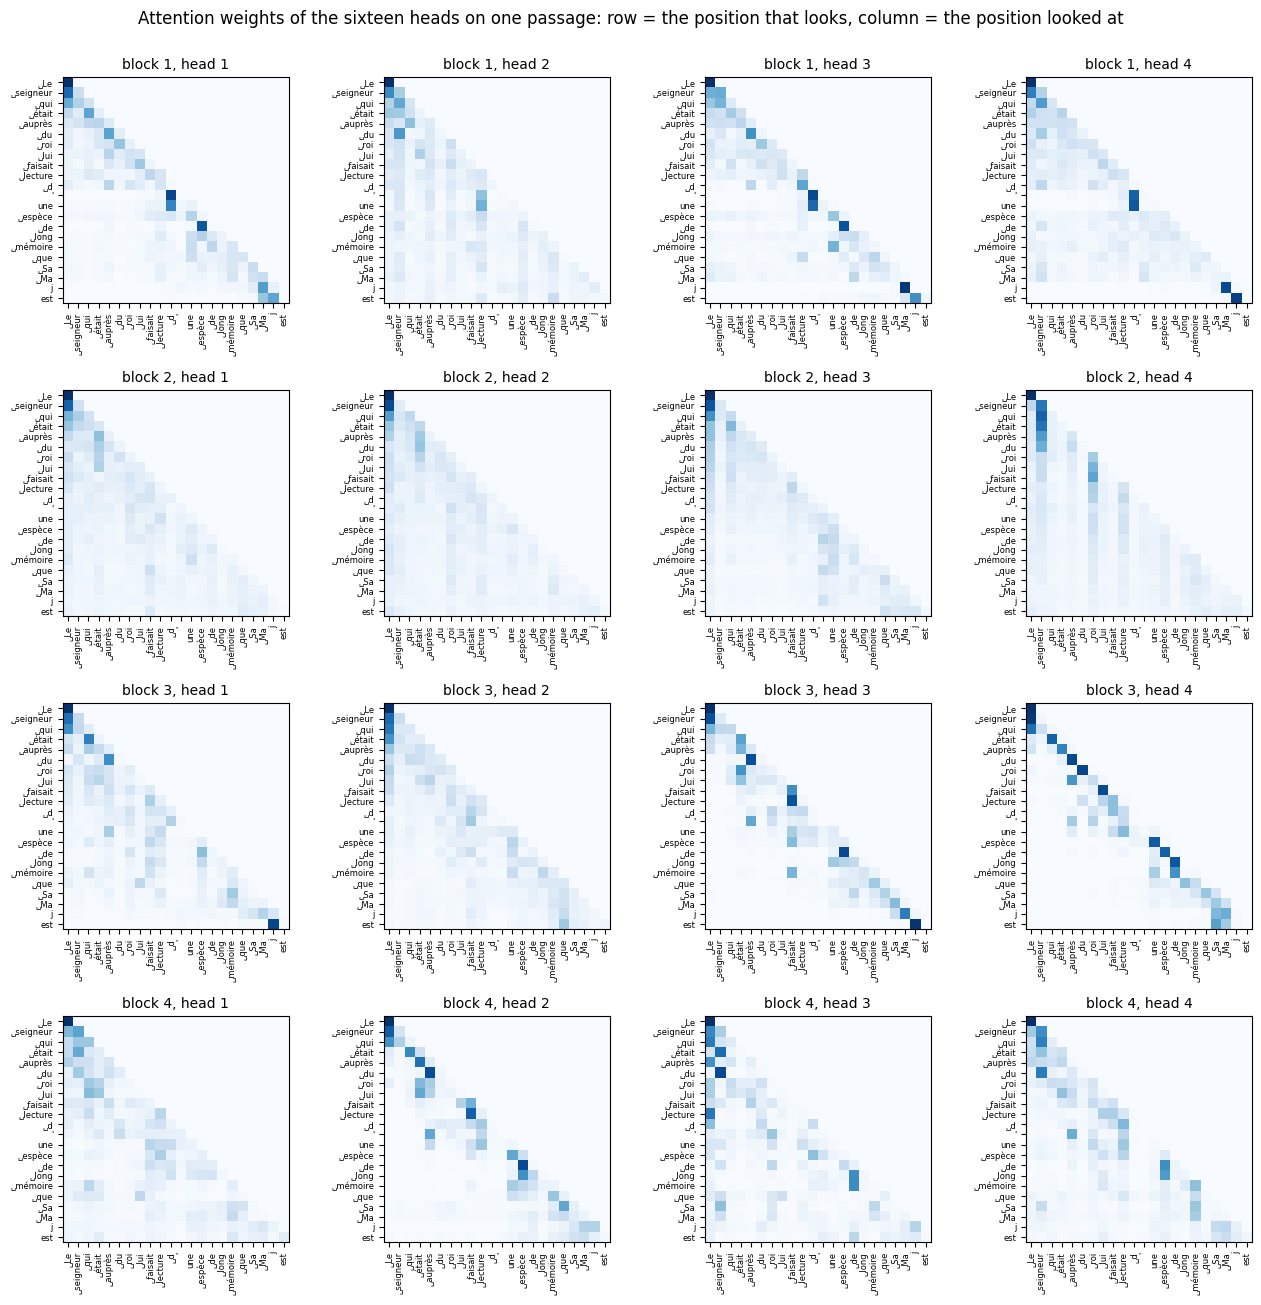

In [9]:
def find_passage(n_tokens=22):
    """The first n_tokens of a sentence of the test split that starts with a capitalised word."""
    ids = data["test"].tolist()
    for j in range(1, len(ids) - n_tokens):
        if tok.decode([ids[j - 1]]).endswith(".") and tok.decode([ids[j]])[:2] in (" L", " I", " E", " C", " Q", " J"):
            return ids[j:j + n_tokens]

passage = find_passage()
labels = [tok.decode([i]).replace(" ", "␣") for i in passage]
print(tok.decode(passage))
gpt.eval()
with torch.no_grad(): gpt(torch.tensor([passage], device=device))
fig, axes = plt.subplots(4, 4, figsize=(13, 13))
for l, block in enumerate(gpt.blocks):
    for hd in range(4):
        ax = axes[l, hd]; ax.imshow(block.attn.weights[0, hd].cpu().numpy(), cmap="Blues", vmin=0, vmax=1)
        ax.set_title(f"block {l + 1}, head {hd + 1}", fontsize=10)
        ax.set_xticks(range(len(passage))); ax.set_xticklabels(labels, rotation=90, fontsize=6); ax.set_yticks(range(len(passage))); ax.set_yticklabels(labels, fontsize=6)
plt.suptitle("Attention weights of the sixteen heads on one passage: row = the position that looks, column = the position looked at", y=1.0)
plt.tight_layout(); plt.show()
_ = gpt.train()

Each panel is one head: a lower-triangular picture, dark where a position gives weight to another. Some heads are almost a diagonal shifted by one (the position looks at the token just before it: a *previous-token head*), some look at the first tokens of the passage whatever the query, some spread over the whole past, some pick one specific earlier token. No one told the heads what to look at; they are the questions the model found useful for predicting Hugo. The next figure summarises the same thing over many passages.

### 7.2 Near or far: the average behaviour of each head

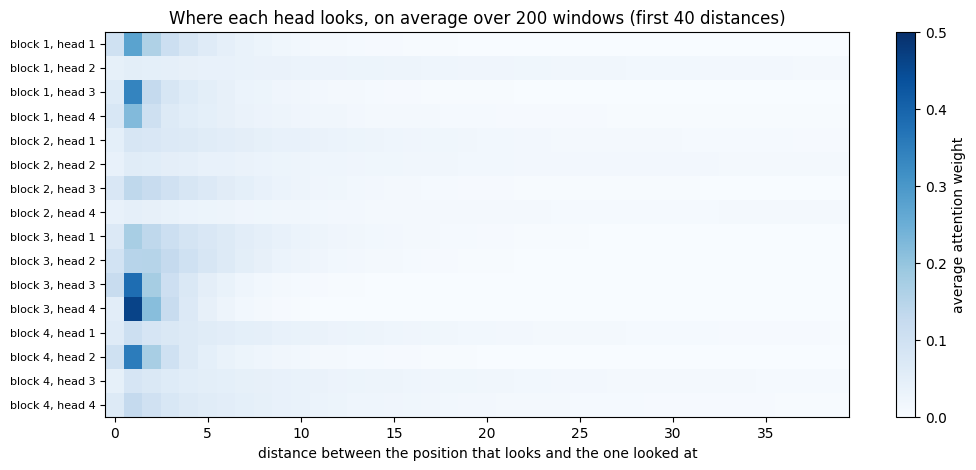

,on itself (d = 0),on the previous token (d = 1),beyond 8 tokens back
share of a position's attention,,,
"block 1, head 1",0.10,0.27,0.14
"block 1, head 2",0.04,0.05,0.70
"block 1, head 3",0.06,0.34,0.22
"block 1, head 4",0.08,0.22,0.37
"block 2, head 1",0.05,0.08,0.52
"block 2, head 2",0.04,0.06,0.68
"block 2, head 3",0.07,0.14,0.32
"block 2, head 4",0.04,0.04,0.78
"block 3, head 1",0.07,0.17,0.23


In [10]:
@torch.no_grad()
def attention_by_distance(model, n=200, K=CTX):
    """Per head, over n test windows: the average weight given to the position at distance delta (among the positions that can see
    that far), and the share of a position's weight that goes to itself, to the previous token, and beyond 8 tokens back."""
    torch.manual_seed(3); x, _ = batch("test", n, K); model.eval(); L, H = len(model.blocks), model.blocks[0].attn.heads
    acc, shares = torch.zeros(L, H, K), torch.zeros(L, H, 3)
    for j in range(0, n, 50):
        model(x[j:j + 50]); m = min(50, n - j)
        for l, block in enumerate(model.blocks):
            w = block.attn.weights                                        # (B, heads, T, T)
            for delta in range(K): acc[l, :, delta] += w.diagonal(offset=-delta, dim1=-2, dim2=-1).mean((0, 2)).cpu() * m
            shares[l, :, 0] += w.diagonal(dim1=-2, dim2=-1).mean((0, 2)).cpu() * m
            shares[l, :, 1] += w.diagonal(offset=-1, dim1=-2, dim2=-1).mean((0, 2)).cpu() * m
            shares[l, :, 2] += torch.stack([w[:, :, t, :t - 8].sum(-1) for t in range(9, K)]).mean((0, 1)).cpu() * m
    model.train(); return acc / n, shares / n

by_distance, shares = attention_by_distance(gpt)
plt.figure(figsize=(12, 5))
plt.imshow(by_distance.reshape(-1, CTX)[:, :40], aspect="auto", cmap="Blues", vmin=0, vmax=0.5)
plt.yticks(range(16), [f"block {l + 1}, head {h + 1}" for l in range(4) for h in range(4)], fontsize=8); plt.xlabel("distance between the position that looks and the one looked at")
plt.colorbar(label="average attention weight"); plt.title("Where each head looks, on average over 200 windows (first 40 distances)"); plt.show()
summary_heads = pd.DataFrame({"on itself (d = 0)": shares[:, :, 0].flatten(), "on the previous token (d = 1)": shares[:, :, 1].flatten(),
                              "beyond 8 tokens back": shares[:, :, 2].flatten()},
                             index=[f"block {l + 1}, head {h + 1}" for l in range(4) for h in range(4)]).round(2)
summary_heads.rename_axis("share of a position's attention")

Every head has a signature. A bright second column is a head that looks at the previous token (several of them, in blocks 3 and 4); a long pale tail, a head that spreads over the whole context; the darker cells in the first columns of some heads of block 2 are the first tokens of the window, which many heads use as a resting place when nothing else is worth looking at. The last column of the table is the share of a position's attention that goes beyond the CNN's window: from a few percent for the previous-token heads to more than half for the diffuse ones. The LSTM had to carry that far context through a hundred gates; a head reaches it in one product.

### 7.3 Does the order matter?

Attention itself does not know where tokens are; the position vectors do. If the model uses them, shuffling the past should hurt. Take 600 windows, keep the last token in place, and shuffle the others, either all of them or only those more than sixteen tokens back.

In [11]:
@torch.no_grad()
def shuffled_surprise(model, keep_last=0, n=600, K=CTX):
    """Surprise at the last position when the earlier tokens are shuffled (all of them, or all but the last keep_last)."""
    torch.manual_seed(1); x, y = batch("test", n, K); model.eval(); g = torch.Generator(device="cpu").manual_seed(0); xs = x.clone()
    for i in range(n):
        span = K - 1 - keep_last; xs[i, :span] = x[i, torch.randperm(span, generator=g).to(device)]
    nll = sum(F.cross_entropy(model(xs[j:j + 200])[:, -1], y[j:j + 200, -1], reduction="sum").item() for j in range(0, n, 200))
    model.train(); return nll / n / math.log(2) / chars_per_token["test"]

pd.DataFrame({name: {"intact": context_curve(m, ks=(128,))[128], "last 16 tokens intact, the rest shuffled": shuffled_surprise(m, keep_last=16),
                     "everything before the last token shuffled": shuffled_surprise(m, keep_last=0)}
              for name, m in [("LSTM", lstm), ("Transformer", gpt)]}).round(3).rename_axis("bits per char at the last position")

,LSTM,Transformer
bits per char at the last position,,
intact,1.593,1.560
"last 16 tokens intact, the rest shuffled",1.612,1.575
everything before the last token shuffled,2.245,2.109


Shuffling everything before the last token costs both models about half a bit per character: both use the order, and the position vectors do their job. But keeping only the last sixteen tokens in order brings almost all of it back, at a cost of two hundredths: what both models take from the far context is mostly *which* tokens were there, not their order. Now the question that matters: what does attention buy that recurrence could not?

## 8. What attention buys

### 8.1 The context curve, five models

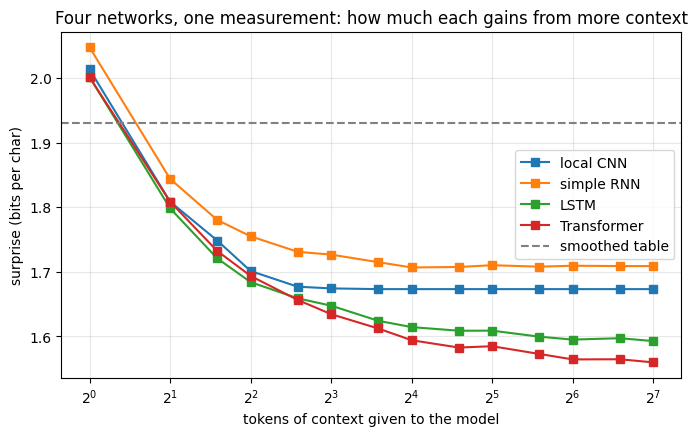

,1,2,3,4,6,8,12,16,24,32,48,64,96,128
local CNN,2.013,1.808,1.748,1.701,1.677,1.674,1.673,1.673,1.673,1.673,1.673,1.673,1.673,1.673
simple RNN,2.047,1.844,1.780,1.755,1.731,1.727,1.715,1.707,1.707,1.710,1.708,1.709,1.709,1.709
LSTM,2.001,1.798,1.721,1.684,1.659,1.648,1.624,1.614,1.609,1.609,1.600,1.595,1.597,1.593
Transformer,2.001,1.808,1.732,1.694,1.656,1.634,1.612,1.594,1.583,1.585,1.573,1.564,1.565,1.560


In [12]:
def plot_curves(curves, title):
    plt.figure(figsize=(8, 4.5))
    for name, c in curves.items():
        plt.plot(c.index, c.values, "s-", label=name)
    plt.axhline(TABLE_BITS_PER_CHAR, color="gray", ls="--", label="smoothed table")
    plt.xscale("log", base=2); plt.xlabel("tokens of context given to the model"); plt.ylabel("surprise (bits per char)")
    plt.grid(alpha=.3); plt.legend(); plt.title(title); plt.show()

curves = {name: context_curve(m) for name, m in [("local CNN", cnn), ("simple RNN", rnn), ("LSTM", lstm), ("Transformer", gpt)]}
plot_curves(curves, "Four networks, one measurement: how much each gains from more context")
pd.DataFrame(curves).T.round(3)

Up to four tokens of context the Transformer is no better than the LSTM, a hair worse even: like the LSTM against the CNN in session 2, **it does not win by being a better local model**. From six tokens on its curve is the lowest, and the gap with the LSTM keeps widening up to about 32 tokens, where both curves become nearly flat, within the noise of 600 windows. Between 8 and 128 tokens the Transformer gains 0.075 bits per character and the LSTM 0.055: attention takes more from the far context. What limits the far end here is the models, five million parameters trained for fifteen minutes, not the mechanism; the window of 128 is a choice of this notebook (the position matrix has 128 rows), and larger models keep gaining for thousands of tokens.

### 8.2 The gradient reaches any distance in one hop

Redo the measurement of session 2: on a fresh, untrained network, the size of the training signal that reaches the token at distance $d$ from the prediction.

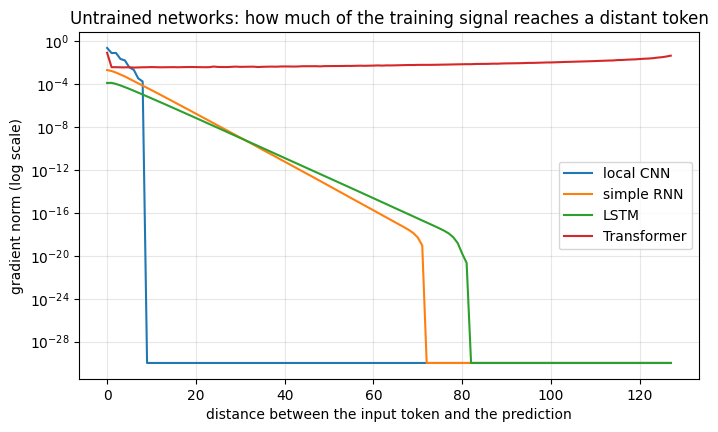

In [13]:
def gradient_by_distance(model, n=64, K=CTX):
    """Norm of d(surprise at the last position) / d(embedding of the token at distance d), averaged over n windows."""
    was_training = model.training; model.eval(); torch.manual_seed(2)
    x, y = batch("test", n, K)
    emb = model.emb(x).detach().requires_grad_(True)
    F.cross_entropy(model(x, emb=emb)[:, -1], y[:, -1]).backward()
    g = emb.grad.norm(dim=2).mean(dim=0).flip(0).cpu().numpy()        # index d = distance d from the last token
    model.zero_grad(set_to_none=True); model.train(was_training)
    return g

torch.manual_seed(0)
fresh = {"local CNN": LocalCNN().to(device), "simple RNN": Recurrent("rnn").to(device), "LSTM": Recurrent("lstm").to(device), "Transformer": TinyGPT().to(device)}
plt.figure(figsize=(8, 4.5))
for name, m in fresh.items():
    plt.semilogy(gradient_by_distance(m) + 1e-30, label=name)
plt.xlabel("distance between the input token and the prediction"); plt.ylabel("gradient norm (log scale)")
plt.grid(alpha=.3); plt.legend(); plt.title("Untrained networks: how much of the training signal reaches a distant token"); plt.show()

The CNN's signal stops at its window; the recurrent networks' decays exponentially with the distance, because it travels through every step in between (the LSTM is at its default initialisation, gates half open, as in session 2). The Transformer's is **flat**: the token at distance 127 receives as much signal as the token at distance 1, because attention connects the two positions directly, in one product. Nothing to learn about long-range dependencies is out of reach of the training signal, on the first day of training. This is limit 1 lifted.

### 8.3 All positions at once

Attention processes a whole window with matrix products; there is no state to carry from one position to the next. Time it: one batch of 32 windows of 128 tokens, 4,096 tokens in all, for each model.

In [14]:
@torch.no_grad()
def tokens_per_second(model, B=32, T=CTX, n=5):
    sync = torch.cuda.synchronize if device.type == "cuda" else torch.mps.synchronize if device.type == "mps" else (lambda: None)
    model.eval(); x = torch.randint(0, V, (B, T), device=device); model(x); sync(); t0 = time.time()
    for _ in range(n): model(x)
    sync(); model.train(); return B * T * n / (time.time() - t0)

pd.Series({name: tokens_per_second(m) for name, m in [("local CNN", cnn), ("simple RNN", rnn), ("LSTM", lstm), ("Transformer", gpt)]}
          ).round(0).rename("tokens per second (forward pass, 32 windows of 128)").to_frame()

,"tokens per second (forward pass, 32 windows of 128)"
local CNN,984858.0
simple RNN,267136.0
LSTM,470156.0
Transformer,589656.0


The recurrent networks pay for their sequential loop; the Transformer is faster than both, and not far from the CNN, although it reads the whole window, not nine tokens (the exact numbers depend on the machine and on how well each operation is optimised; the order is what matters). This is limit 2 lifted, and it is the reason the architecture could be trained on the corpora of today: billions of tokens, thousands of GPUs, all positions at once. The price is in the $T \times T$ matrix of scores: attention costs grow with the *square* of the window, which is why context length is a currency in large models, and why so much engineering goes into it.

### 8.4 The memory is the past itself

The LSTM had to decide, at every token, what to keep in 512 numbers. The Transformer keeps nothing: at every position it has the keys and values of *all* the earlier positions, and looks them up when it needs them. A clean test on Hugo: take a **rare token**, a name or an unusual word, that appears twice within a window, and measure how well each model predicts the **second** occurrence, as a function of the distance to the first. A model that can look back and copy should do well whatever the distance; a model that must remember through a summary should degrade.

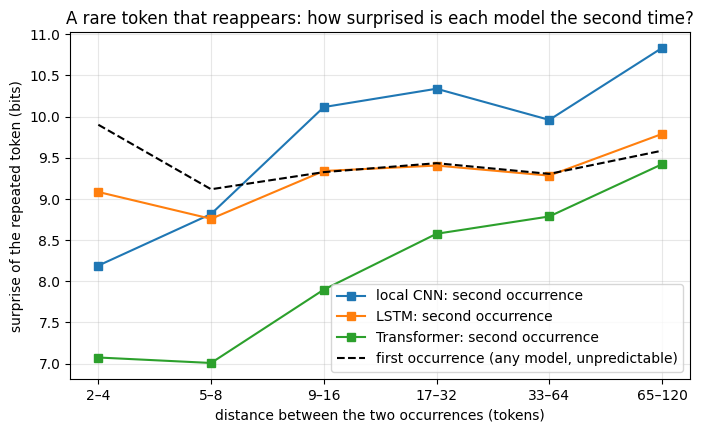

,2–4,5–8,9–16,17–32,33–64,65–120
"bits, by distance between the two occurrences",,,,,,
local CNN,8.19,8.82,10.12,10.34,9.96,10.83
LSTM,9.09,8.76,9.34,9.41,9.28,9.79
Transformer,7.07,7.01,7.90,8.58,8.79,9.42
first occurrence,9.90,9.12,9.33,9.43,9.30,9.59


In [15]:
def repeated_token_pairs(bins=((2, 4), (5, 8), (9, 16), (17, 32), (33, 64), (65, 120)), rare=300, per_bin=300):
    """Positions j of the test split where a token rare in training reappears, d positions after its previous occurrence."""
    counts = torch.bincount(data["train"], minlength=V); ids = data["test"].tolist(); last, pairs = {}, {b: [] for b in bins}
    for j, t in enumerate(ids):
        if j >= CTX and counts[t] < rare and t in last:
            d = j - last[t]
            for b in bins:
                if b[0] <= d <= b[1]: pairs[b].append((j, d))
        last[t] = j
    rng = random.Random(0)
    for b in bins: rng.shuffle(pairs[b]); pairs[b] = pairs[b][:per_bin]
    return pairs

@torch.no_grad()
def bits_on_pairs(model, pairs):
    """Surprise, in bits, of the repeated token at its second occurrence (the window ends just before it) and at its first."""
    ids = data["test"]; model.eval(); out = {}
    for b, lst in pairs.items():
        second, first = [], []
        for j0 in range(0, len(lst), 100):
            chunk = lst[j0:j0 + 100]
            for which, offs in (("second", 0), ("first", None)):
                js = [j if offs == 0 else j - d for j, d in chunk]
                x = torch.stack([ids[j - CTX:j] for j in js]).to(device); y = torch.tensor([ids[j] for j in js], device=device)
                lp = torch.log_softmax(model(x)[:, -1], -1).gather(1, y[:, None])[:, 0] / math.log(2)
                (second if which == "second" else first).extend((-lp).tolist())
        out[f"{b[0]}–{b[1]}"] = dict(second=np.mean(second), first=np.mean(first), n=len(lst))
    model.train(); return out

pairs = repeated_token_pairs()
results = {name: bits_on_pairs(m, pairs) for name, m in [("local CNN", cnn), ("LSTM", lstm), ("Transformer", gpt)]}
plt.figure(figsize=(8, 4.5))
for name, r in results.items():
    plt.plot(list(r), [v["second"] for v in r.values()], "s-", label=f"{name}: second occurrence")
plt.plot(list(results["LSTM"]), [v["first"] for v in results["LSTM"].values()], "k--", label="first occurrence (any model, unpredictable)")
plt.xlabel("distance between the two occurrences (tokens)"); plt.ylabel("surprise of the repeated token (bits)"); plt.grid(alpha=.3); plt.legend()
plt.title("A rare token that reappears: how surprised is each model the second time?"); plt.show()
table = pd.DataFrame({name: {k: round(v["second"], 2) for k, v in r.items()} for name, r in results.items()}).T
table.loc["first occurrence"] = [round(v["first"], 2) for v in results["LSTM"].values()]
table.rename_axis("bits, by distance between the two occurrences")

The dashed line is the surprise at the first occurrence: the token is rare, and every model is surprised by nine to ten bits. The second occurrence is where the models differ. The LSTM's curve sits on the dashed line at every distance: **it gains nothing from having seen the token before**, even four tokens earlier. Its memory was never taught to keep a rare word for later; whatever it stored about it was overwritten. The CNN gains a bit within its window and loses it beyond. The Transformer is the only one that **copies**: two to three bits gained when the first occurrence is within eight tokens, still half a bit at 17–32, a few tenths at 65–120. The gain fades with distance, because looking up "the same token as now, earlier, and what came with it" is a two-step trick that this five-million-parameter model has only started to learn; large models learn it very well. But it exists, and it is the small-scale version of what a large model does with a name from the beginning of a long document. Nothing was summarised: the first occurrence was still there, in the keys and values, and a head went to get it. This is limit 3 lifted.

### 8.5 Are all heads useful?

Sixteen heads; switch them off one at a time (zero the head's output, keep everything else) and measure the surprise on a slice of the test text.

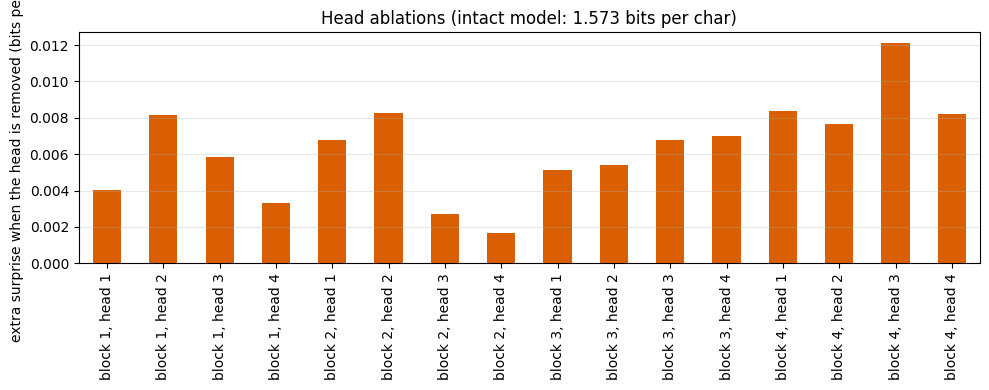

In [16]:
base = surprise(gpt, limit=150_000) / math.log(2) / chars_per_token["test"]; ablation = {}
for l, block in enumerate(gpt.blocks):
    for hd in range(block.attn.heads):
        mask = torch.ones(block.attn.heads, device=device); mask[hd] = 0; block.attn.head_mask = mask
        ablation[f"block {l + 1}, head {hd + 1}"] = surprise(gpt, limit=150_000) / math.log(2) / chars_per_token["test"] - base
        block.attn.head_mask = None
plt.figure(figsize=(10, 4)); pd.Series(ablation).plot.bar(color="#d95f02"); plt.ylabel("extra surprise when the head is removed (bits per char)")
plt.title(f"Head ablations (intact model: {base:.3f} bits per char)"); plt.grid(alpha=.3, axis="y"); plt.tight_layout(); plt.show()

Removing one head costs between two thousandths and a little over one hundredth of a bit per character; no single head is indispensable, and the sixteen costs add up to more than the gap with the LSTM: the heads share the work, with some redundancy. The cheapest head to remove is the most diffuse one (block 2, head 4), which spreads its weight almost uniformly over the past: an almost uniform average is the bag of section 2.1, and it carries little. Not all heads are equal; this is the observation behind head pruning, and the starting point of the work that tries to read what each head computes.

## 9. Samples

In [17]:
for name, m in [("LSTM", lstm), ("Transformer", gpt)]:
    print(f"── {name} ──")
    for seed, prompt in enumerate(["L'amour est", "Les startups de l'IA sont"]):
        print(f"  {prompt!r} -> {generate(m, prompt, seed=seed).replace(chr(10), ' ')}")
    print()

── LSTM ──


  "L'amour est" -> L'amour est possible. On n'eut pas de rosée dans la cellule. Les quatre autres étaient les portes, les halles, les deux détailles, les colonnes, les chambres, une fanfare, les chaînes, les comptants, les genies de l'oeuf. Les balles
  "Les startups de l'IA sont" -> Les startups de l'IA sont de la tête. Tout en lisant, la porte qui s'étouffe de la façon de son œil se promène, les mains se content, les canons vont ondillers. Il fait horreur dans les ténèbres, l'homme n'est plus le fait, et

── Transformer ──


  "L'amour est" -> L'amour est possible. On voit parfois un air, et tout est sûr. L'aïeul, lui dit:--C'est moi, je le vois. Ce que je suis amoureux, J'ai souffert ainsi. Je vous l'ignore, et je suis heureux. Le doux père était joyeux. La


  "Les startups de l'IA sont" -> Les startups de l'IA sont de la place. Tout en fait surgissant la forme de l'un dans l'autre. Sortie, Pfrappe, Bellac, Gomer Justine, Dorni, Met, Cambagon, Mazamène, Ruy



## 10. Scoreboard, and where this leaves us

The whole course so far in one table. Every model was tuned on the validation set and trained for the same fifteen minutes on the same corpus; only the architecture changes.

In [18]:
gain = {name: round(c[8] - c[128], 3) for name, c in curves.items()}          # bits per char gained from context beyond 8 tokens
summary = pd.DataFrame(scoreboard).set_index("model")
summary["parameters (M)"] = [None, 3.6, 3.1, 5.9, 5.2]
summary["gain from context beyond 8 tokens"] = [0.0, gain["local CNN"], gain["simple RNN"], gain["LSTM"], gain["Transformer"]]
summary

,loss,perplexity,bits_per_char,parameters (M),gain from context beyond 8 tokens
model,,,,,
"smoothed table, memory 2",4.676,107.4,1.930,NaN,0.000
local CNN,4.119,61.5,1.700,3.6,0.001
simple RNN,4.233,68.9,1.747,3.1,0.018
LSTM,3.966,52.8,1.637,5.9,0.055
Transformer,3.869,47.9,1.597,5.2,0.075


Table < RNN < CNN < LSTM < Transformer, on one corpus, one tokenizer, one measurement. The mechanism that wins is a soft lookup over the whole past, stacked with a small network and a residual stream: nothing in it is specific to Hugo, to French, or to text. What we trained here has 5 million parameters and read 3 million tokens; GPT-2 (2019) has the same architecture with 124 million parameters, and the largest models of today the same one again, thousands of times larger, on trillions of tokens. The next steps of the course are about what happens when this recipe is scaled up, and what has to be added to it to turn a predictor of the next token into an assistant.

Two things to keep from the measurements. Attention wins by reaching further and by copying, not by predicting the next token better locally: the context curves are together at short range, and the repeated-token test is where the two mechanisms part. And the price of that reach is the square of the window, which is where the engineering of large models begins.

---
*Appendix: the hyperparameters.* Depth, width, number of heads, dropout and learning rate were chosen on the validation set with a search that is not part of this notebook; the notebook shows the winning values, and the checkpoint is the best validation weights of a fifteen-minute run, trained with PyTorch's own Transformer layer (the class in section 5 computes exactly the same function, and loads its weights under other names). Bahdanau, Cho & Bengio (2014), *Neural Machine Translation by Jointly Learning to Align and Translate*, for the first attention; Vaswani et al. (2017), *Attention Is All You Need*, for the Transformer; Radford et al. (2019), *Language Models are Unsupervised Multitask Learners*, for GPT-2, whose pre-norm block this notebook uses.